In [42]:
print("Hello World")

Hello World


In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [44]:
import os

os.getcwd()

'C:\\Users\\karan\\HealthInsuranceProject'

In [45]:
os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'Health_insu_premium.ipynb',
 'Health_insu_premium.xlsx',
 'premium_model.pkl',
 'requirements.txt']

In [46]:
# os.listdir('Downloads')

In [47]:
df = pd.read_excel(
    r"C:\Users\karan\HealthInsuranceProject\Health_insu_premium.xlsx"
)

df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


In [48]:
df.shape

(10000, 15)

In [49]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Physical_Activity',
       'Stress_Level', 'Number Of Dependants', 'BMI_Category',
       'Smoking_Status', 'Employment_Status', 'Income_Level', 'Income_Lakhs',
       'Medical History', 'Insurance_Plan', 'Annual_Premium_Amount'],
      dtype='object')

In [50]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    10000 non-null  int64 
 1   Gender                 10000 non-null  object
 2   Region                 10000 non-null  object
 3   Marital_status         10000 non-null  object
 4   Physical_Activity      10000 non-null  object
 5   Stress_Level           10000 non-null  object
 6   Number Of Dependants   10000 non-null  int64 
 7   BMI_Category           10000 non-null  object
 8   Smoking_Status         9991 non-null   object
 9   Employment_Status      9993 non-null   object
 10  Income_Level           9982 non-null   object
 11  Income_Lakhs           10000 non-null  int64 
 12  Medical History        10000 non-null  object
 13  Insurance_Plan         10000 non-null  object
 14  Annual_Premium_Amount  10000 non-null  int64 
dtypes: int64(4), object(

In [51]:
df.isnull().sum()

Age                       0
Gender                    0
Region                    0
Marital_status            0
Physical_Activity         0
Stress_Level              0
Number Of Dependants      0
BMI_Category              0
Smoking_Status            9
Employment_Status         7
Income_Level             18
Income_Lakhs              0
Medical History           0
Insurance_Plan            0
Annual_Premium_Amount     0
dtype: int64

In [52]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,41.316300,3.192900,23.339900,19505.063900
std,57.971661,21.650454,32.302974,8893.649171
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11777.750000
50%,37.000000,2.000000,16.000000,19312.000000
75%,50.000000,3.000000,31.000000,26494.500000
max,1178.000000,456.000000,960.000000,45854.000000


In [53]:
#check duplicate rows
df.duplicated().sum()

np.int64(0)

In [54]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

In [55]:
df.columns = df.columns.str.strip()

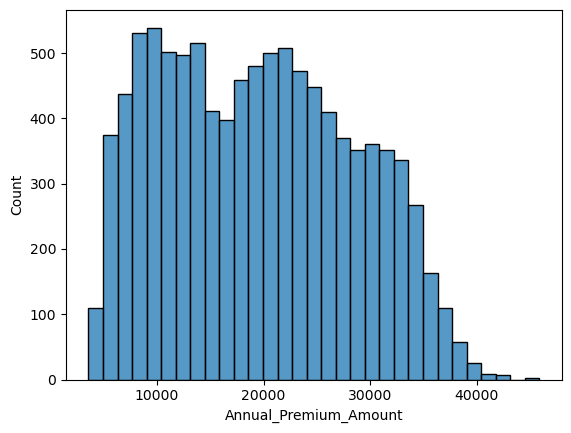

In [56]:
sns.histplot(df["Annual_Premium_Amount"])
plt.show()

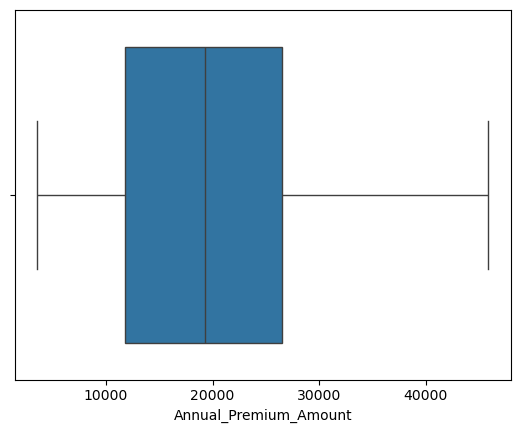

In [57]:
sns.boxplot(x=df["Annual_Premium_Amount"])
plt.show()

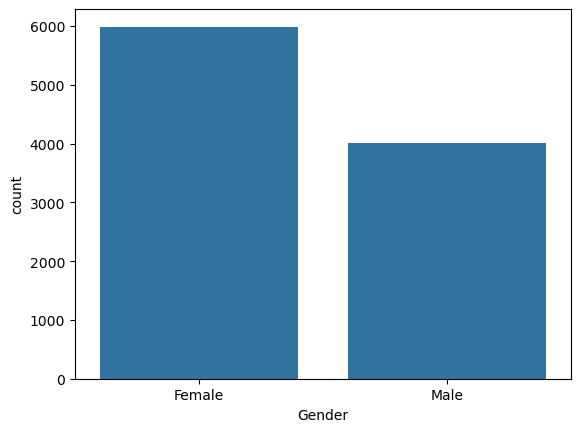

In [58]:
sns.countplot(data=df,x="Gender")
plt.show()

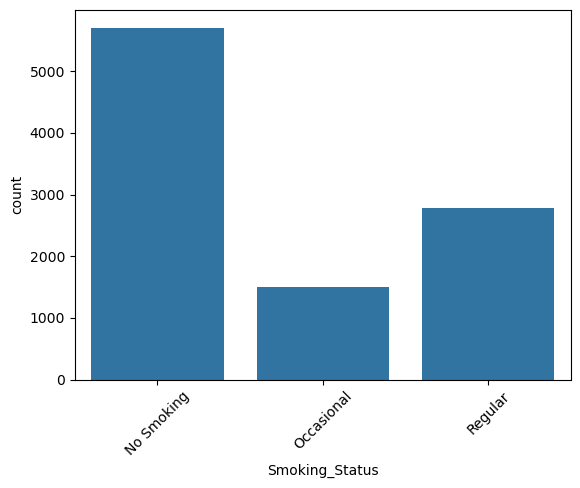

In [59]:
sns.countplot(data=df, x="Smoking_Status")
plt.xticks(rotation=45)
plt.show()

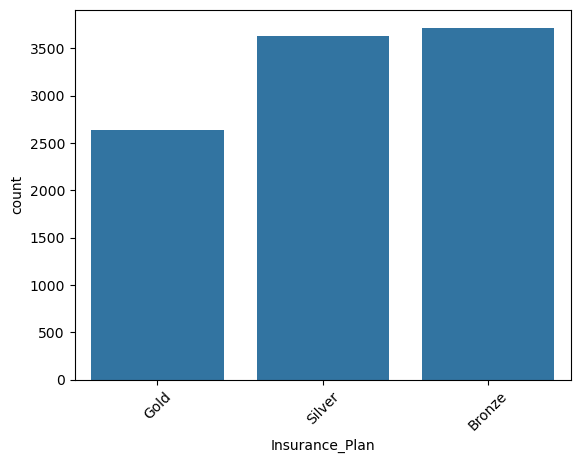

In [60]:
sns.countplot(data=df, x="Insurance_Plan")
plt.xticks(rotation=45)
plt.show()

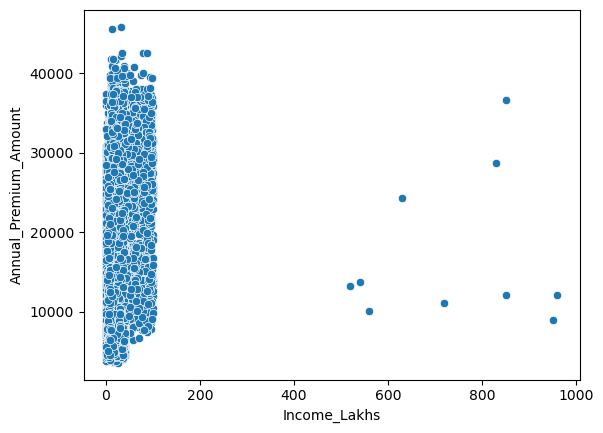

In [61]:
sns.scatterplot(
    data=df,
    x="Income_Lakhs",
    y="Annual_Premium_Amount"
)
plt.show()

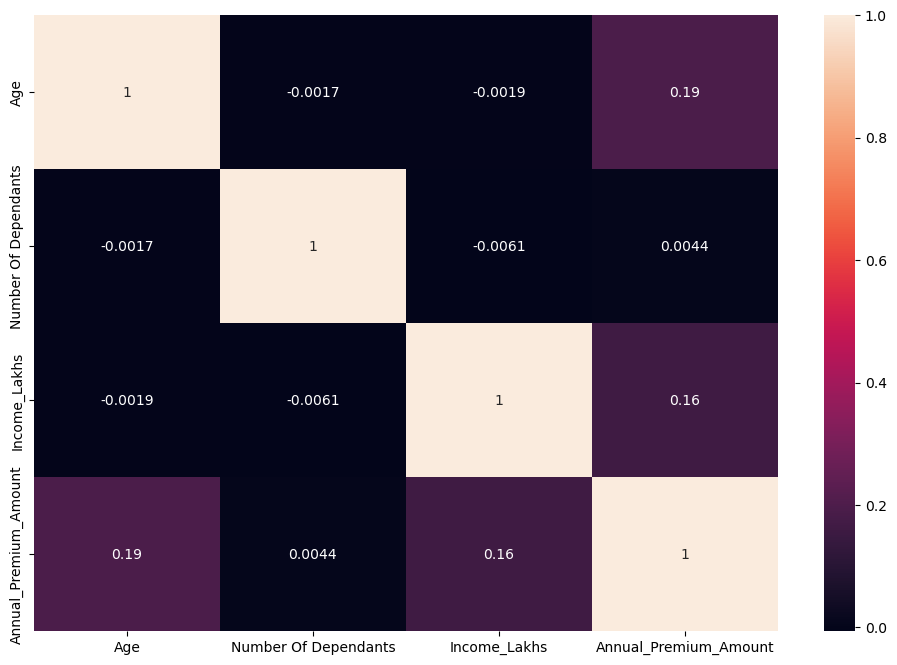

In [62]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [63]:
physical_score = {
    "High": 0,
    "Medium": 1,
    "Low": 4
}

stress_score = {
    "High": 4,
    "Medium": 1,
    "Low": 0
}

df["Lifestyle_Risk_Score"] = (
    df["Physical_Activity"].map(physical_score)
    + df["Stress_Level"].map(stress_score)
)

print(df["Lifestyle_Risk_Score"].isnull().sum())

0


In [64]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Region,Marital_status,Physical_Activity,Stress_Level,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Lifestyle_Risk_Score
0,56,0,2,1,2,2,2,0,0,2,1,37,5,1,27944,2
1,38,0,0,0,1,0,5,2,1,0,0,10,7,2,21108,8
2,18,0,3,1,2,0,0,0,0,0,2,9,7,0,8459,5
3,55,1,0,0,0,2,3,2,1,1,2,9,8,2,21685,1
4,22,1,2,1,2,0,2,0,2,2,0,13,6,0,15984,5


In [65]:
X = df.drop('Annual_Premium_Amount', axis=1)

y = df['Annual_Premium_Amount']

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Age                    10000 non-null  int64
 1   Gender                 10000 non-null  int64
 2   Region                 10000 non-null  int64
 3   Marital_status         10000 non-null  int64
 4   Physical_Activity      10000 non-null  int64
 5   Stress_Level           10000 non-null  int64
 6   Number Of Dependants   10000 non-null  int64
 7   BMI_Category           10000 non-null  int64
 8   Smoking_Status         10000 non-null  int64
 9   Employment_Status      10000 non-null  int64
 10  Income_Level           10000 non-null  int64
 11  Income_Lakhs           10000 non-null  int64
 12  Medical History        10000 non-null  int64
 13  Insurance_Plan         10000 non-null  int64
 14  Annual_Premium_Amount  10000 non-null  int64
 15  Lifestyle_Risk_Score   10000 non-null

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [68]:
print(X.isnull().sum())

Age                     0
Gender                  0
Region                  0
Marital_status          0
Physical_Activity       0
Stress_Level            0
Number Of Dependants    0
BMI_Category            0
Smoking_Status          0
Employment_Status       0
Income_Level            0
Income_Lakhs            0
Medical History         0
Insurance_Plan          0
Lifestyle_Risk_Score    0
dtype: int64


In [69]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [70]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

pred_dt = dt.predict(X_test)

In [71]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators":[50,100,200],
    "max_depth":[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)
#
best_model = grid.best_estimator_
pred = best_model.predict(X_test)

{'max_depth': None, 'n_estimators': 200}
0.9805101238994383


In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train,y_train)

pred_gb = gb.predict(X_test)

In [73]:
# feature of random forest
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
13,Insurance_Plan,0.487815
0,Age,0.413998
7,BMI_Category,0.023473
12,Medical History,0.023263
14,Lifestyle_Risk_Score,0.020996
8,Smoking_Status,0.020283
11,Income_Lakhs,0.003113
6,Number Of Dependants,0.001497
2,Region,0.001297
9,Employment_Status,0.001039


In [74]:
# feature of decision tree
dt_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

dt_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Age,0.544823
13,Insurance_Plan,0.356058
12,Medical History,0.026457
7,BMI_Category,0.024042
14,Lifestyle_Risk_Score,0.020480
8,Smoking_Status,0.020040
11,Income_Lakhs,0.002975
6,Number Of Dependants,0.001481
2,Region,0.000976
9,Employment_Status,0.000614


In [75]:
# feature of gradient boosting
gb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb.feature_importances_
})

gb_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
0,Age,0.549457
13,Insurance_Plan,0.341974
12,Medical History,0.038768
7,BMI_Category,0.026573
8,Smoking_Status,0.021546
14,Lifestyle_Risk_Score,0.021334
11,Income_Lakhs,0.000202
6,Number Of Dependants,0.000060
10,Income_Level,0.000050
3,Marital_status,0.000022


In [76]:
# feature of linear regression
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coef.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
13,Insurance_Plan,3073.622955
9,Employment_Status,2000.227683
8,Smoking_Status,1584.525643
14,Lifestyle_Risk_Score,715.947592
7,BMI_Category,424.881200
1,Gender,139.747365
2,Region,54.448869
11,Income_Lakhs,36.068080
5,Stress_Level,31.215055
0,Age,14.344032


In [77]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("R² Score:", r2_score(y_test, pred))

print("MAE:", mean_absolute_error(y_test, pred))

print("RMSE:", mean_squared_error(y_test, pred)**0.5)

R² Score: 0.9816316927292748
MAE: 837.2382832142857
RMSE: 1189.119012945946


In [78]:
import joblib

joblib.dump(best_model, "premium_model.pkl", compress=9)

['premium_model.pkl']

In [79]:
import os

os.listdir()

['.ipynb_checkpoints',
 'app.py',
 'Health_insu_premium.ipynb',
 'Health_insu_premium.xlsx',
 'premium_model.pkl',
 'requirements.txt']

In [80]:
#model comparision
from sklearn.metrics import r2_score

results = pd.DataFrame({

"Model":[
"Linear Regression",
"Decision Tree",
"Random Forest",
"Gradient Boosting"
],

"R2":[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_dt),

r2_score(y_test,pred),

r2_score(y_test,pred_gb)

]

})

results

,Model,R2
0,Linear Regression,0.473143
1,Decision Tree,0.971638
2,Random Forest,0.981632
3,Gradient Boosting,0.989518


In [81]:
#percentage error calculation
error_percent = (
    abs(pred - y_test) / y_test
) * 100

greater_than_10 = (
    error_percent > 10
).mean() * 100

print(f"Percentage with error >10%: {greater_than_10:.2f}%")

Percentage with error >10%: 13.00%


In [41]:
import os

print(os.path.getsize("premium_model.pkl")/(1024*1024))

22.952838897705078
